<a href="https://www.kaggle.com/code/omborse771924/gold-price-analysis-eda?scriptVersionId=340404438" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shakhnoza12/gold-price-analysis-20002026/gold_stock.csv


## Loading Datset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/shakhnoza12/gold-price-analysis-20002026/gold_stock.csv')

In [3]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,GOLD,GOLD,GOLD,GOLD,GOLD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2014-03-17,4.711997032165527,4.85016815549002,4.425025639793251,4.425025639793251,68200
3,2014-03-18,5.048568248748779,5.278853682840762,4.694282757608514,4.711997099740122,135600
4,2014-03-19,4.959996223449707,5.1017102661133835,4.90685354191906,5.013138904980353,25600


In [4]:
df.tail()

,Price,Close,High,Low,Open,Volume
2965,2025-12-24,34.49665069580078,34.86352978677981,33.118371818243254,33.56457438016267,632900
2966,2025-12-26,34.298336029052734,35.40889108972075,33.475332803245784,35.20066272507017,519400
2967,2025-12-29,33.13819885253906,33.765864568292805,32.483764161201734,33.46541808947349,543700
2968,2025-12-30,33.167945861816406,33.60423436098219,32.860558461759986,33.48524727621538,478900
2969,2025-12-31,33.76288604736328,34.07027345633446,33.26710210016989,33.85212730915934,401800


In [5]:
df.info

<bound method DataFrame.info of            Price               Close                High                 Low  \
0         Ticker                GOLD                GOLD                GOLD   
1           Date                 NaN                 NaN                 NaN   
2     2014-03-17   4.711997032165527    4.85016815549002   4.425025639793251   
3     2014-03-18   5.048568248748779   5.278853682840762   4.694282757608514   
4     2014-03-19   4.959996223449707  5.1017102661133835    4.90685354191906   
...          ...                 ...                 ...                 ...   
2965  2025-12-24   34.49665069580078   34.86352978677981  33.118371818243254   
2966  2025-12-26  34.298336029052734   35.40889108972075  33.475332803245784   
2967  2025-12-29   33.13819885253906  33.765864568292805  32.483764161201734   
2968  2025-12-30  33.167945861816406   33.60423436098219  32.860558461759986   
2969  2025-12-31   33.76288604736328   34.07027345633446   33.26710210016989   

       

In [6]:
df.describe

<bound method NDFrame.describe of            Price               Close                High                 Low  \
0         Ticker                GOLD                GOLD                GOLD   
1           Date                 NaN                 NaN                 NaN   
2     2014-03-17   4.711997032165527    4.85016815549002   4.425025639793251   
3     2014-03-18   5.048568248748779   5.278853682840762   4.694282757608514   
4     2014-03-19   4.959996223449707  5.1017102661133835    4.90685354191906   
...          ...                 ...                 ...                 ...   
2965  2025-12-24   34.49665069580078   34.86352978677981  33.118371818243254   
2966  2025-12-26  34.298336029052734   35.40889108972075  33.475332803245784   
2967  2025-12-29   33.13819885253906  33.765864568292805  32.483764161201734   
2968  2025-12-30  33.167945861816406   33.60423436098219  32.860558461759986   
2969  2025-12-31   33.76288604736328   34.07027345633446   33.26710210016989   

     

In [7]:
df.isnull

<bound method DataFrame.isnull of            Price               Close                High                 Low  \
0         Ticker                GOLD                GOLD                GOLD   
1           Date                 NaN                 NaN                 NaN   
2     2014-03-17   4.711997032165527    4.85016815549002   4.425025639793251   
3     2014-03-18   5.048568248748779   5.278853682840762   4.694282757608514   
4     2014-03-19   4.959996223449707  5.1017102661133835    4.90685354191906   
...          ...                 ...                 ...                 ...   
2965  2025-12-24   34.49665069580078   34.86352978677981  33.118371818243254   
2966  2025-12-26  34.298336029052734   35.40889108972075  33.475332803245784   
2967  2025-12-29   33.13819885253906  33.765864568292805  32.483764161201734   
2968  2025-12-30  33.167945861816406   33.60423436098219  32.860558461759986   
2969  2025-12-31   33.76288604736328   34.07027345633446   33.26710210016989   

     

In [8]:
df.isnull().sum()

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

In [9]:
# Check missing values
print(df.isnull().sum())

# Forward Fill
df = df.ffill()

# Verify
print(df.isnull().sum())

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64
Price     0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [10]:
df.duplicated

<bound method DataFrame.duplicated of            Price               Close                High                 Low  \
0         Ticker                GOLD                GOLD                GOLD   
1           Date                GOLD                GOLD                GOLD   
2     2014-03-17   4.711997032165527    4.85016815549002   4.425025639793251   
3     2014-03-18   5.048568248748779   5.278853682840762   4.694282757608514   
4     2014-03-19   4.959996223449707  5.1017102661133835    4.90685354191906   
...          ...                 ...                 ...                 ...   
2965  2025-12-24   34.49665069580078   34.86352978677981  33.118371818243254   
2966  2025-12-26  34.298336029052734   35.40889108972075  33.475332803245784   
2967  2025-12-29   33.13819885253906  33.765864568292805  32.483764161201734   
2968  2025-12-30  33.167945861816406   33.60423436098219  32.860558461759986   
2969  2025-12-31   33.76288604736328   34.07027345633446   33.26710210016989   

 

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

## EDA

Price     float64
Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object
       Price  Close  High  Low  Open  Volume
count    0.0    0.0   0.0  0.0   0.0     0.0
mean     NaN    NaN   NaN  NaN   NaN     NaN
std      NaN    NaN   NaN  NaN   NaN     NaN
min      NaN    NaN   NaN  NaN   NaN     NaN
25%      NaN    NaN   NaN  NaN   NaN     NaN
50%      NaN    NaN   NaN  NaN   NaN     NaN
75%      NaN    NaN   NaN  NaN   NaN     NaN
max      NaN    NaN   NaN  NaN   NaN     NaN


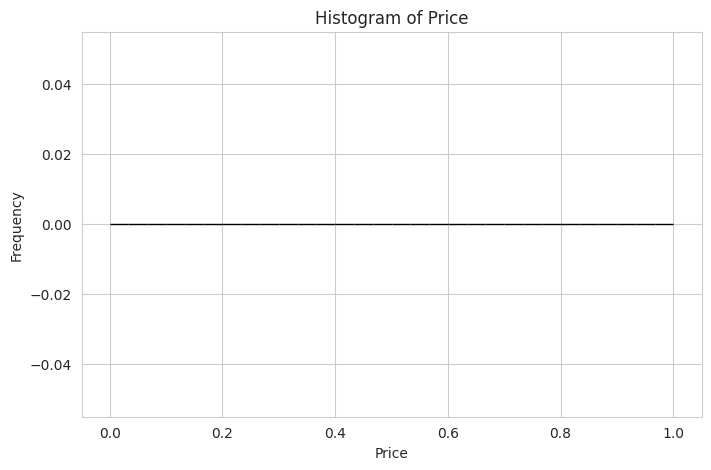

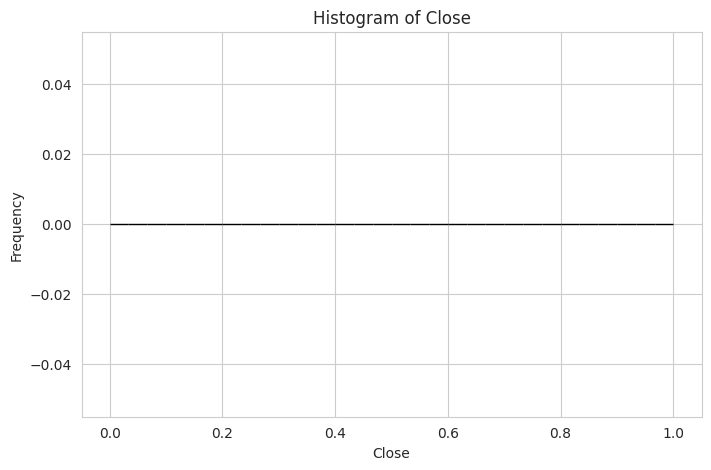

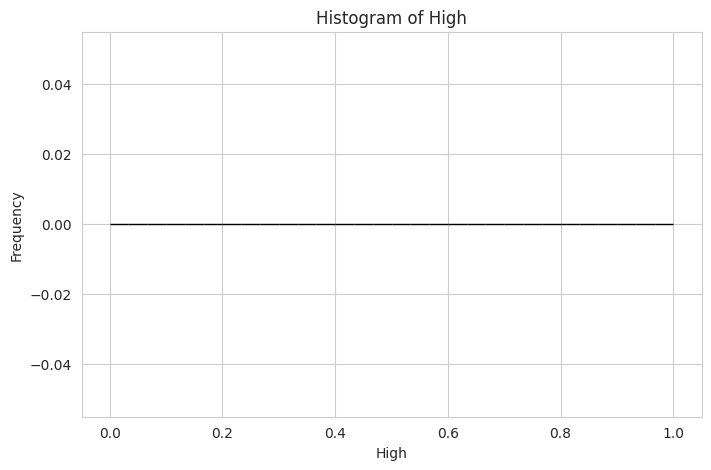

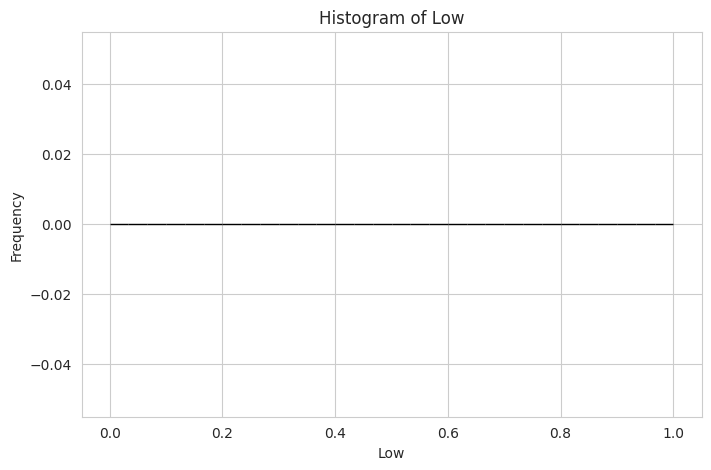

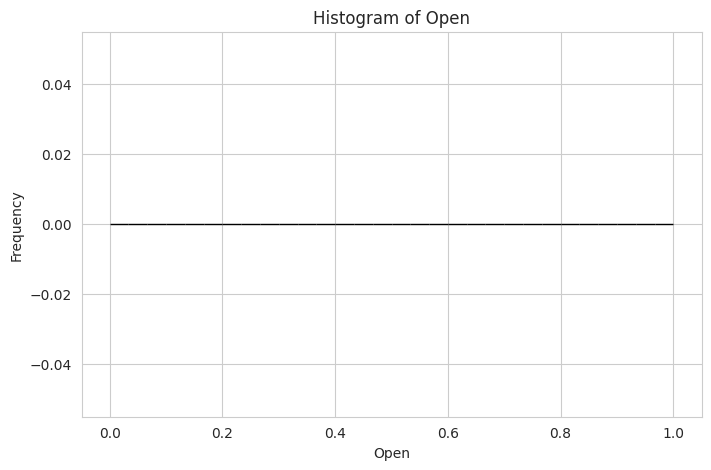

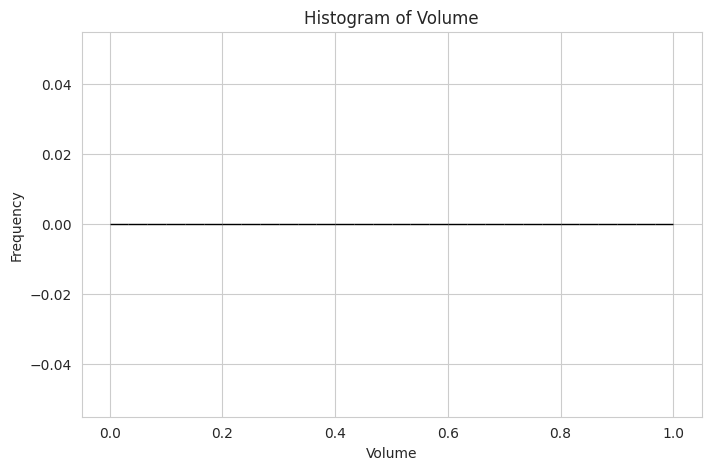

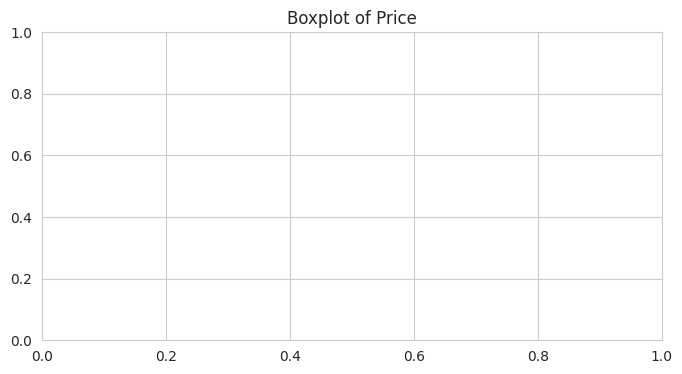

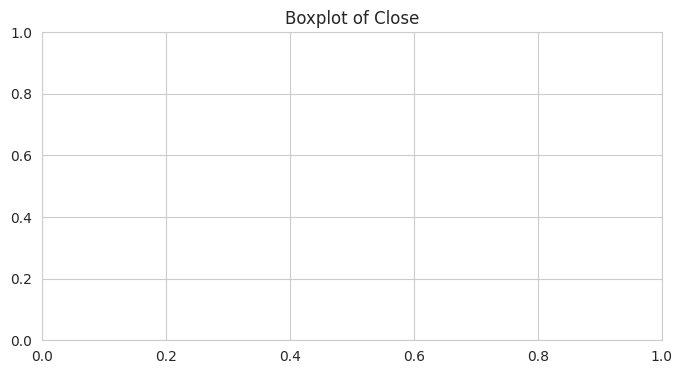

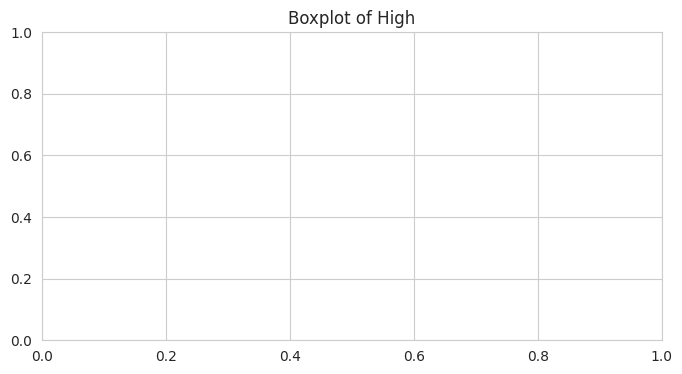

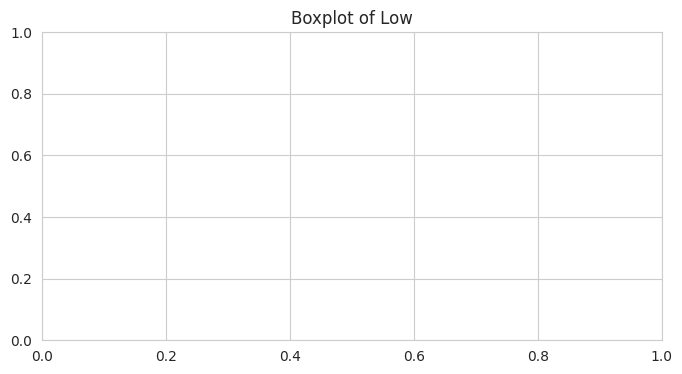

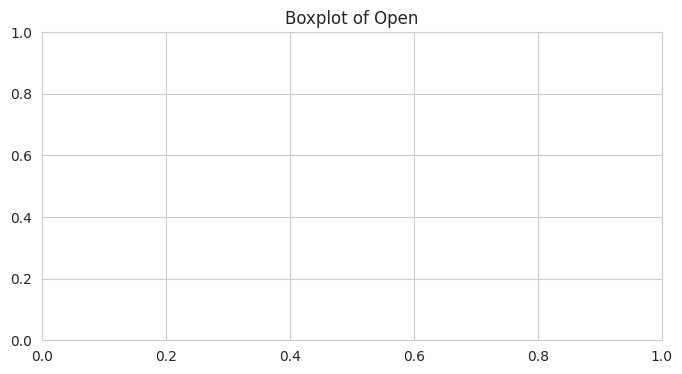

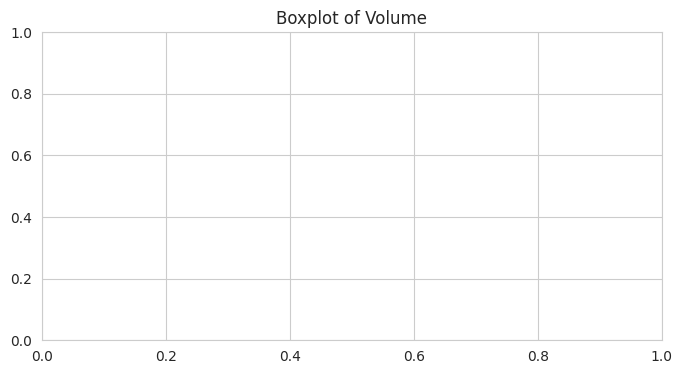

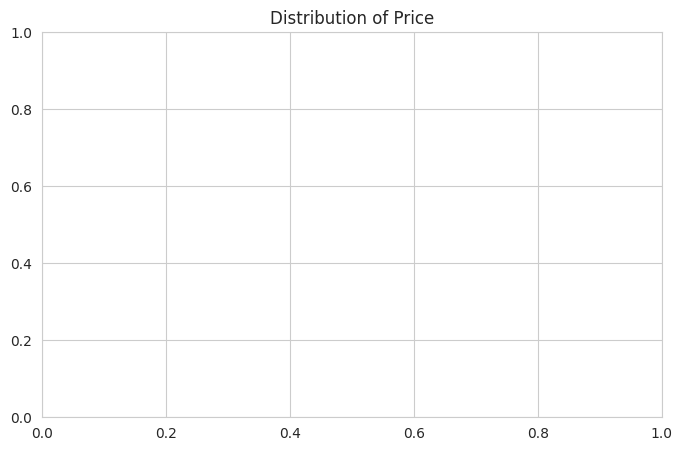

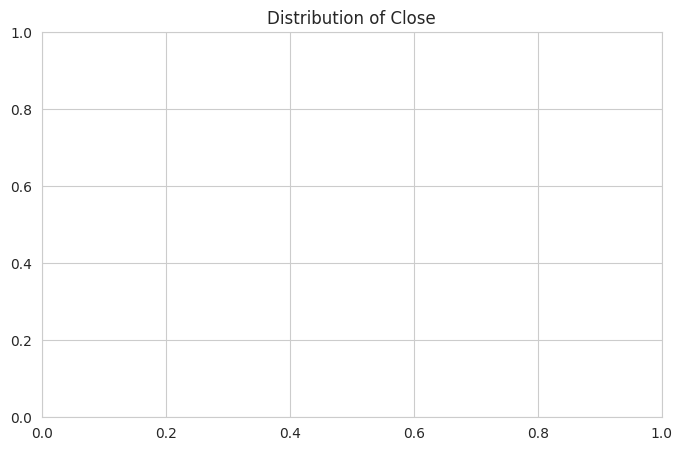

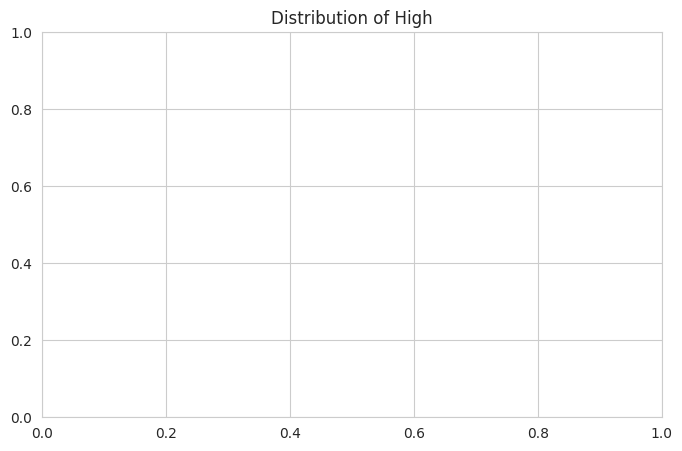

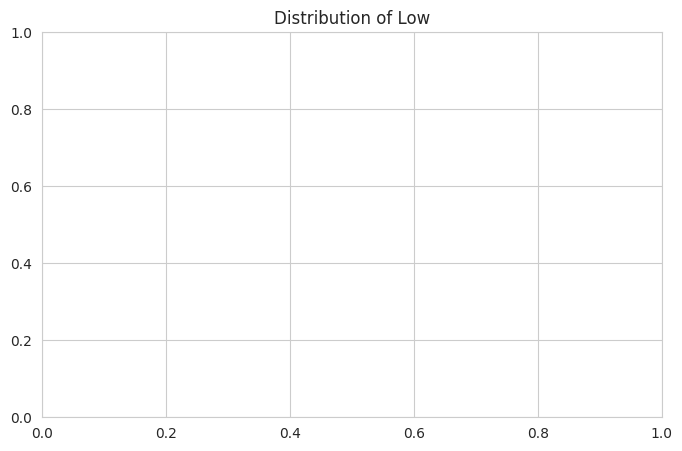

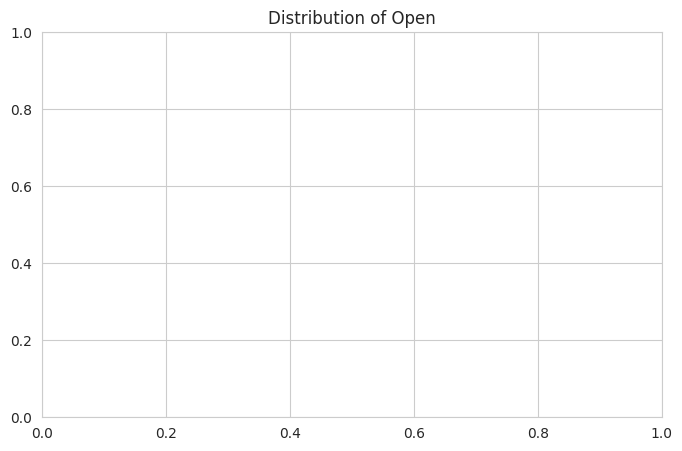

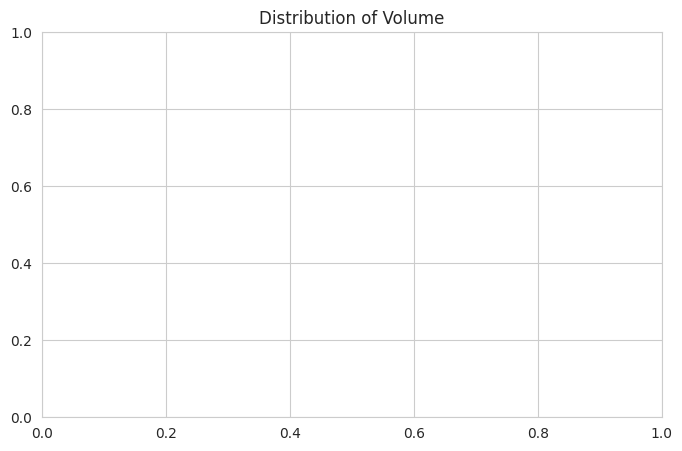

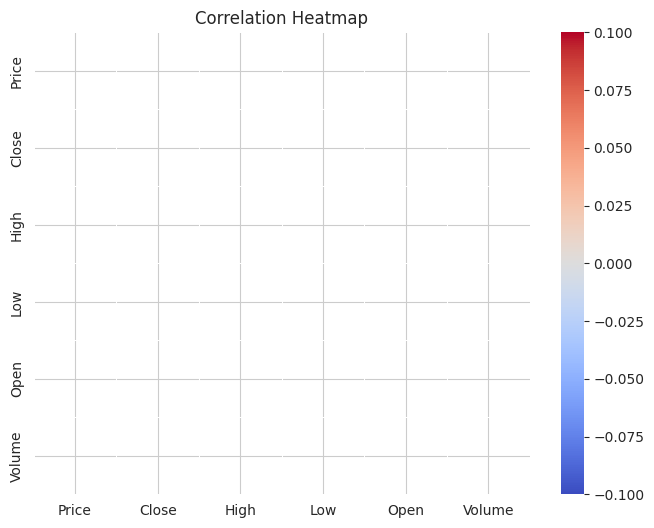

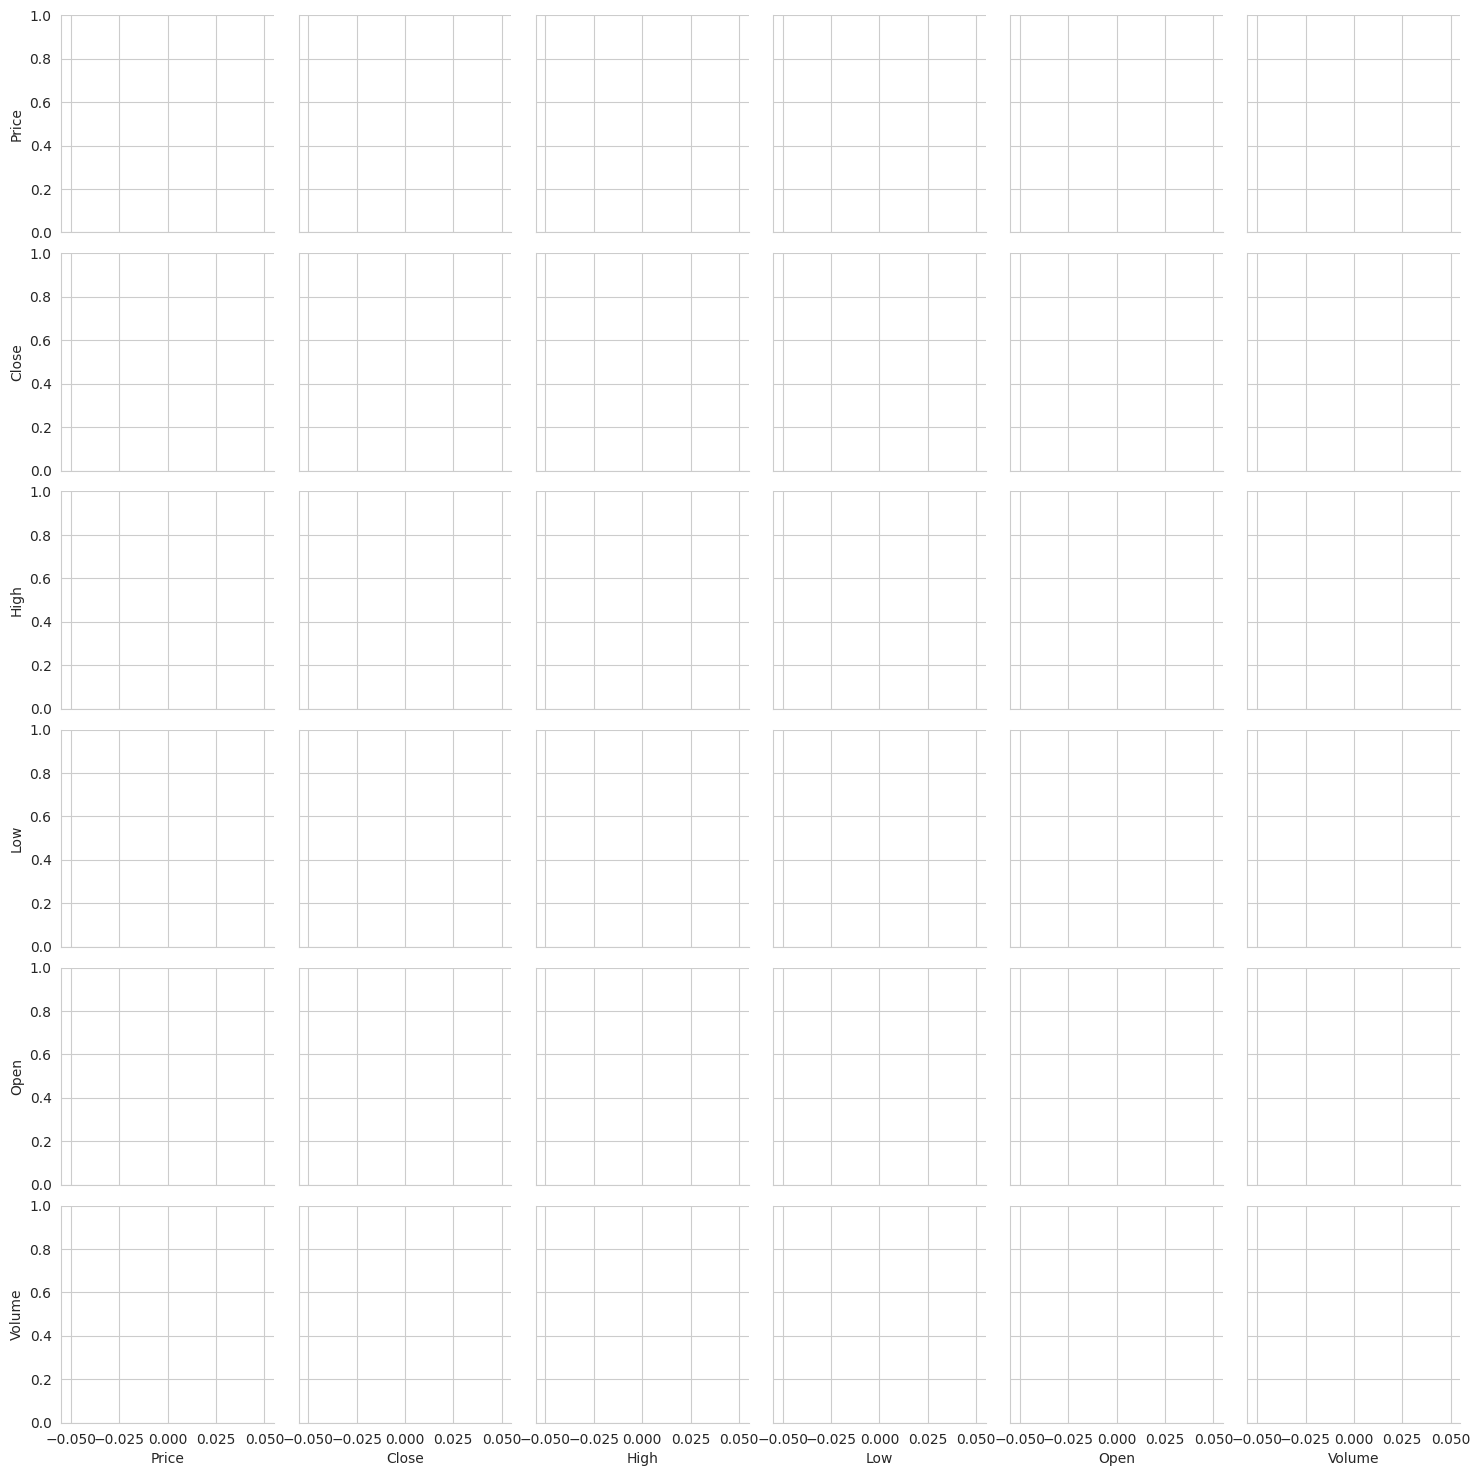

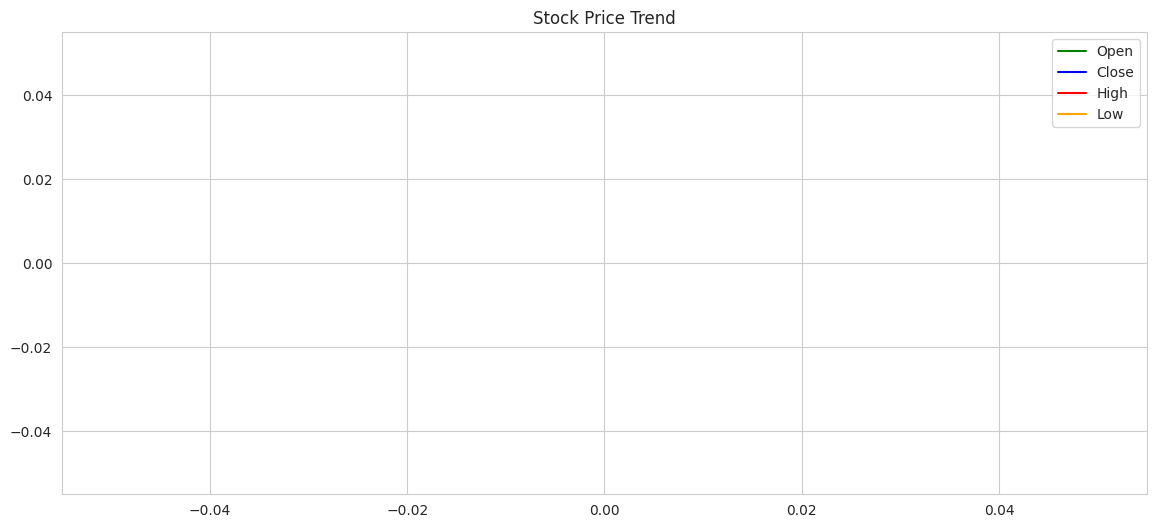

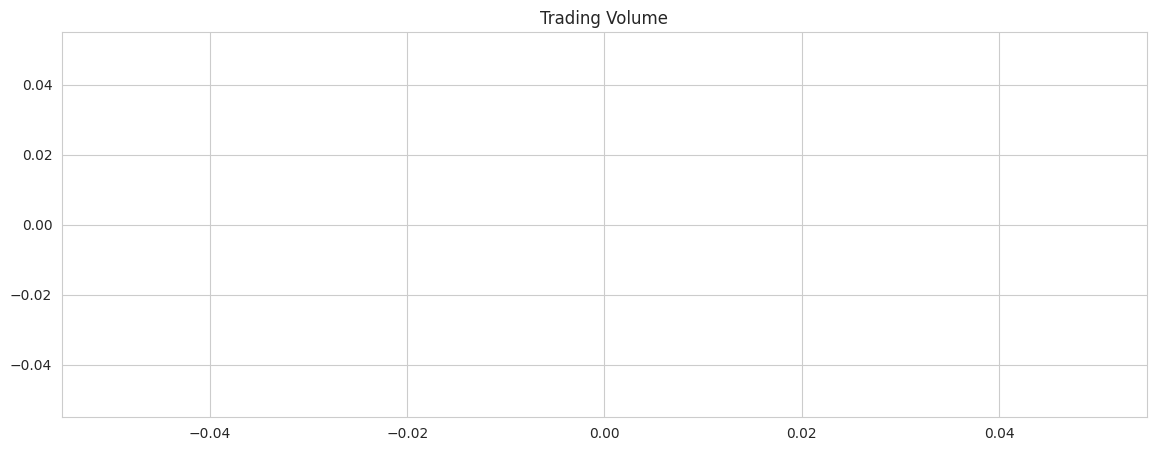

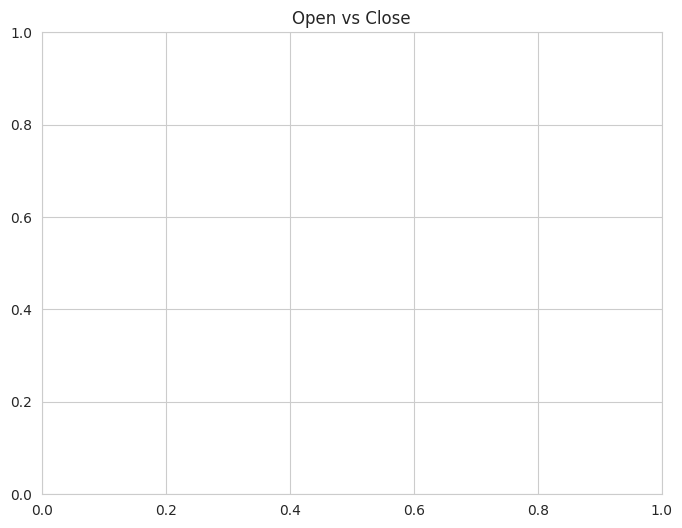

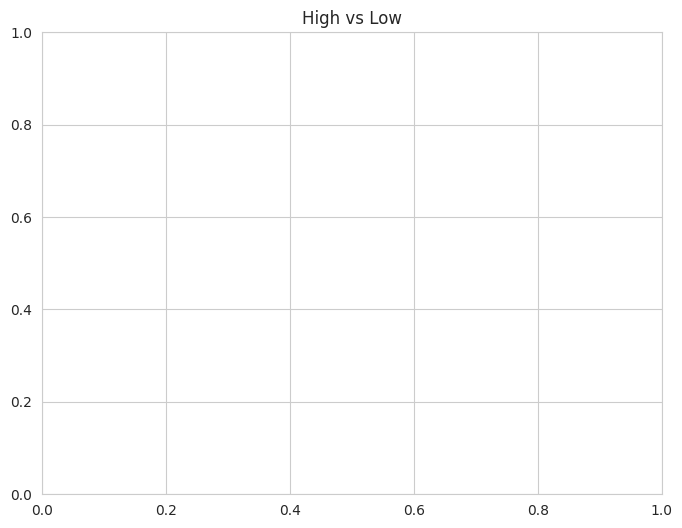

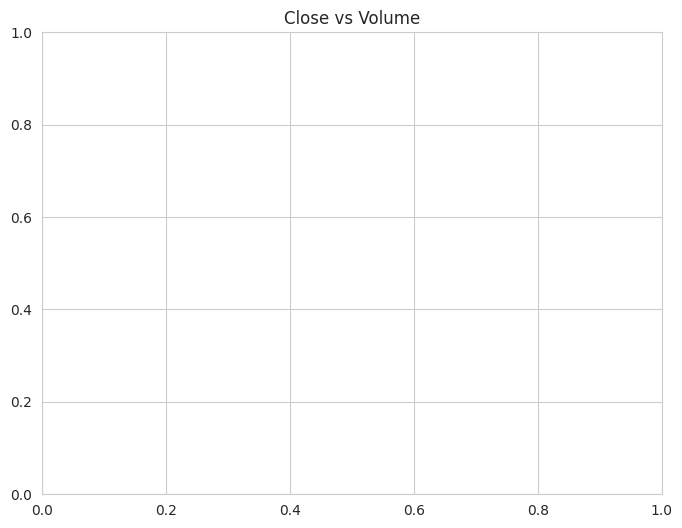

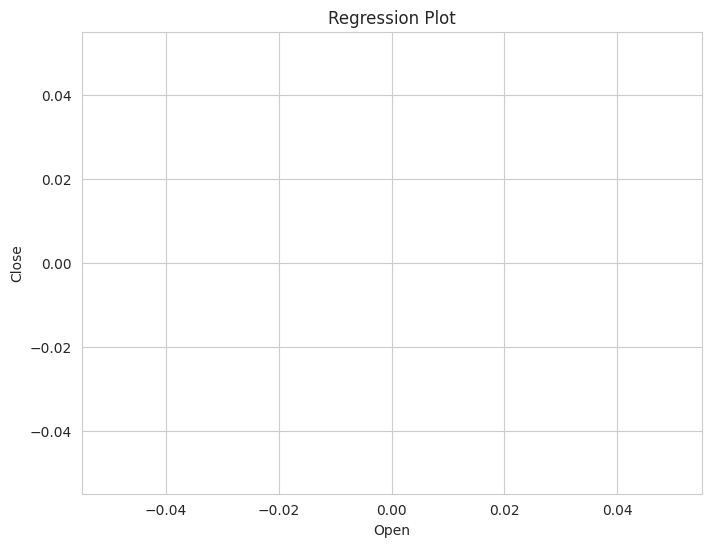

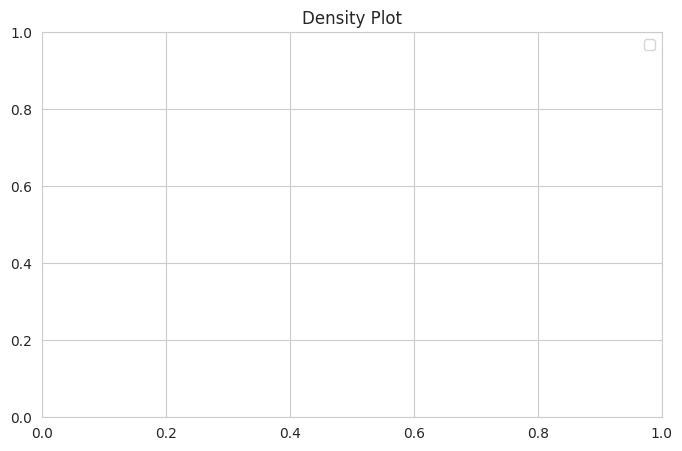

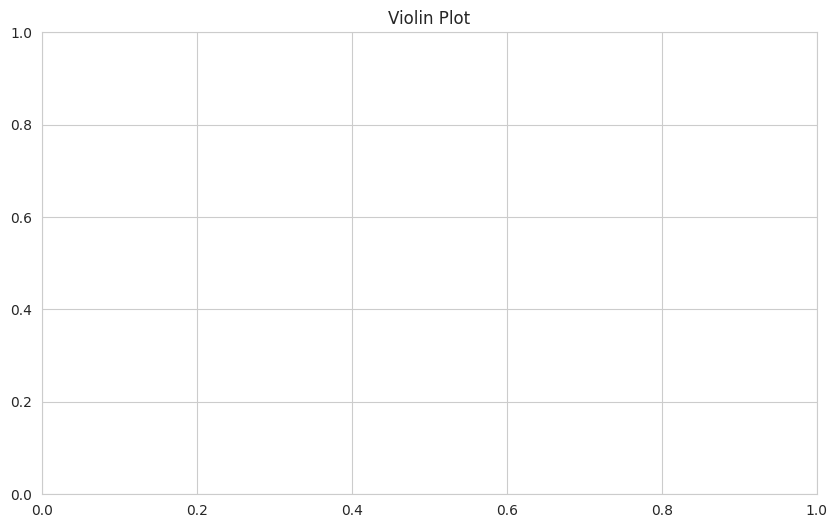

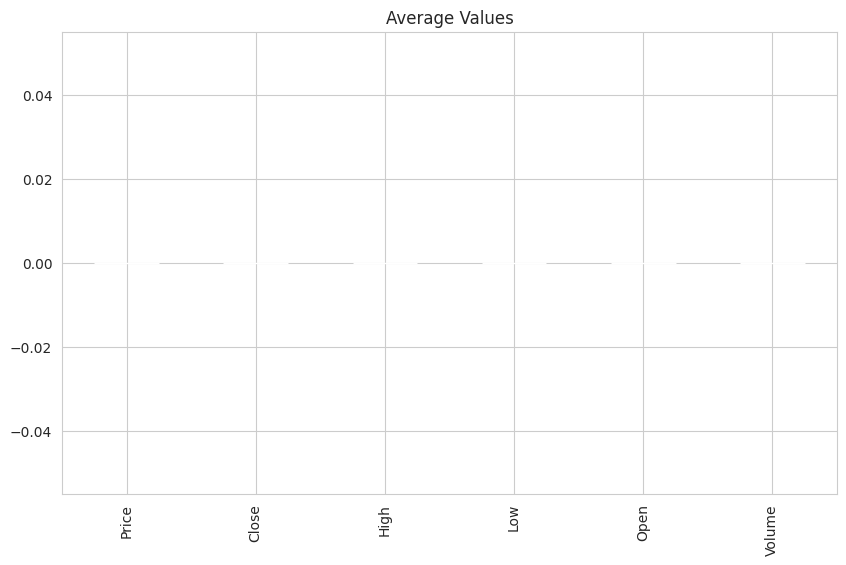

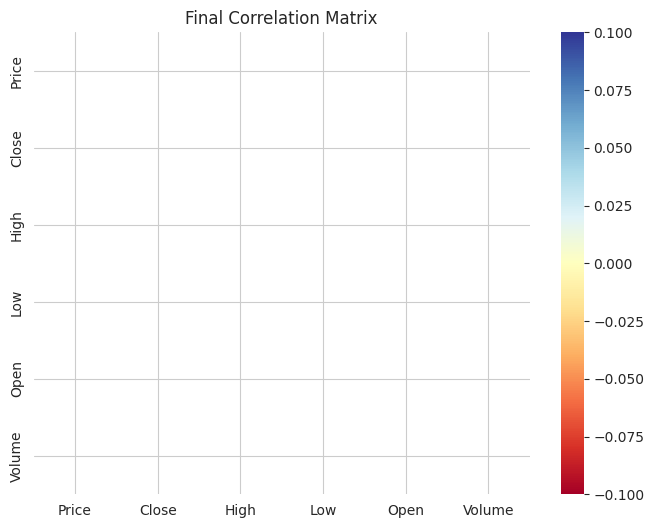

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================
# STYLE
# =====================================

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# =====================================
# NUMERIC COLUMNS
# =====================================

num_cols = ["Price","Close","High","Low","Open","Volume"]

# =====================================
# CONVERT TO NUMERIC
# =====================================

for col in num_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with NaN created during conversion
df = df.dropna(subset=num_cols)

# =====================================
# CHECK DATATYPES
# =====================================

print(df[num_cols].dtypes)

print(df[num_cols].describe())

# =====================================
# HISTOGRAMS
# =====================================

for col in num_cols:

    plt.figure(figsize=(8,5))

    plt.hist(
        df[col],
        bins=30,
        color="skyblue",
        edgecolor="black"
    )

    plt.title(f"Histogram of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()

# =====================================
# BOXPLOTS
# =====================================

colors = ["red","green","blue","orange","purple","brown"]

for col,color in zip(num_cols,colors):

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col],
        color=color
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

# =====================================
# DISTRIBUTION
# =====================================

for col,color in zip(num_cols,colors):

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color=color
    )

    plt.title(f"Distribution of {col}")

    plt.show()

# =====================================
# CORRELATION
# =====================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=.5
)

plt.title("Correlation Heatmap")

plt.show()

# =====================================
# PAIRPLOT
# =====================================

sns.pairplot(df[num_cols])

plt.show()

# =====================================
# LINE CHART
# =====================================

plt.figure(figsize=(14,6))

plt.plot(df["Open"],label="Open",color="green")
plt.plot(df["Close"],label="Close",color="blue")
plt.plot(df["High"],label="High",color="red")
plt.plot(df["Low"],label="Low",color="orange")

plt.legend()

plt.title("Stock Price Trend")

plt.grid(True)

plt.show()

# =====================================
# VOLUME
# =====================================

plt.figure(figsize=(14,5))

plt.plot(df["Volume"],color="purple")

plt.title("Trading Volume")

plt.grid(True)

plt.show()

# =====================================
# SCATTER
# =====================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Open",
    y="Close",
    color="red"
)

plt.title("Open vs Close")

plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="High",
    y="Low",
    color="green"
)

plt.title("High vs Low")

plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Close",
    y="Volume",
    color="blue"
)

plt.title("Close vs Volume")

plt.show()

# =====================================
# REGRESSION
# =====================================

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Open",
    y="Close",
    scatter_kws={"color":"purple"},
    line_kws={"color":"black"}
)

plt.title("Regression Plot")

plt.show()

# =====================================
# KDE
# =====================================

plt.figure(figsize=(8,5))

sns.kdeplot(df["Open"],fill=True,color="green",label="Open")
sns.kdeplot(df["Close"],fill=True,color="blue",label="Close")

plt.legend()

plt.title("Density Plot")

plt.show()

# =====================================
# VIOLIN
# =====================================

plt.figure(figsize=(10,6))

sns.violinplot(data=df[num_cols],palette="Set2")

plt.title("Violin Plot")

plt.show()

# =====================================
# BAR CHART
# =====================================

plt.figure(figsize=(10,6))

df[num_cols].mean().plot(
    kind="bar",
    color=["red","green","blue","orange","purple","brown"]
)

plt.title("Average Values")

plt.grid(True)

plt.show()

# =====================================
# HEATMAP
# =====================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="RdYlBu"
)

plt.title("Final Correlation Matrix")

plt.show()

## Thanks.........Please Upvote